In [ ]:
import os
import gc
import json
import warnings
import numpy as np
import scipy.io as sio
import h5py
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter, defaultdict
from sklearn.model_selection import train_test_split
from collections import Counter


SUBJECTS = ["subj01"]
SUBJECT_INDICES = {"subj01": 0}

NSD_BASE     = "/home/al.pedro.alberti/Downloads/dataset/nsd"
EXPDESIGN    = os.path.join(NSD_BASE, "nsd_expdesign.mat")
COCO_ANNOTATIONS = "/mnt/storage_C1/PedroAlberti/ml2/ml2_trabalhos_2026/trabalho_final/cnn_final/data_loader/auxiliar/instances_train2014.json"

BASE_OUTPUT       = "/home/al.pedro.alberti/Downloads/dataset/data_nsd"
OUTPUT_DIR_TREINO = os.path.join(BASE_OUTPUT, "processed/train")
OUTPUT_DIR_TESTE  = os.path.join(BASE_OUTPUT, "processed/test")

TARGET_SHAPE = (91, 109, 91)  
N_SMALL      = 2135           # Total de trials
N_PER_CLASS  = N_SMALL // 4   # Trials por classe (533)
TEST_SIZE    = 0.2
RANDOM_STATE = 42

SUPERCAT_MAP = {
    "person":      0,
    "animal":      1,
    "vehicle":     2,
    "food":        3,
    "furniture":   3,
    "sports":      3,
    "outdoor":     3,
    "indoor":      3,
    "kitchen":     3,
    "electronic":  3,
    "appliance":   3,
    "accessory":   3,
}

NOMES_CLASSES = {
    0: "Pessoa",
    1: "Animal",
    2: "Veículo",
    3: "Objetos/Cenário",
}

CORES = ["#E63946", "#2A9D8F", "#E9C46A", "#264653"]

In [2]:
def build_coco_label_map(annotations_path: str) -> dict:
    """
    Carrega instances_train2014.json e retorna:
      coco_id (int) → label interno (int)
    Usa a supercategoria dominante por imagem.
    """
    print(f"[coco] Carregando anotações de: {annotations_path} ...")
    with open(annotations_path) as f:
        coco_data = json.load(f)

    cat_to_label = {}
    for cat in coco_data["categories"]:
        label = SUPERCAT_MAP.get(cat["supercategory"], 3)
        cat_to_label[cat["id"]] = label

    image_label_votes = {}
    for ann in coco_data["annotations"]:
        img_id = ann["image_id"]
        label  = cat_to_label.get(ann["category_id"], 3)
        if img_id not in image_label_votes:
            image_label_votes[img_id] = Counter()
        image_label_votes[img_id][label] += 1

    image_to_label = {
        img_id: votes.most_common(1)[0][0]
        for img_id, votes in image_label_votes.items()
    }

    print(f"[coco] {len(image_to_label):,} imagens catalogadas.")
    return image_to_label


def build_trial_to_coco(expdesign_path: str, subject: str) -> np.ndarray:
    """
    Lê nsd_expdesign.mat e retorna array (30000,) com o coco_id global
    para cada trial do sujeito.
    """
    mat        = sio.loadmat(expdesign_path)
    mo         = mat["masterordering"].flatten()
    subjectim  = mat["subjectim"]
    subj_idx   = SUBJECT_INDICES[subject]

    coco_ids = subjectim[subj_idx, mo - 1]

    print(f"[expdesign] {subject}: {len(coco_ids)} trials mapeados")
    print(f"[expdesign] COCO IDs únicos: {len(np.unique(coco_ids))}")
    return coco_ids.astype(np.int32)


def normalize_betas(betas: np.ndarray) -> np.ndarray:
    """
    Z-score por voxel ao longo do tempo (eixo 0 = trials).
    """
    betas = betas.astype(np.float32)
    betas = np.nan_to_num(betas, nan=0.0, posinf=0.0, neginf=0.0)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        mean = betas.mean(axis=0, keepdims=True)
        std  = betas.std(axis=0, keepdims=True)

    std = np.where(std < 1e-8, 1.0, std)
    return (betas - mean) / std


def resize_volume(vol: np.ndarray, target: tuple) -> torch.Tensor:
    """
    Limpa NaNs e redimensiona (X,Y,Z) → target via interpolação trilinear.
    """
    vol = np.nan_to_num(vol, nan=0.0, posinf=0.0, neginf=0.0)
    t   = torch.tensor(vol).unsqueeze(0).unsqueeze(0).float()
    t   = F.interpolate(t, size=target, mode='trilinear', align_corners=False)
    return t.squeeze(0).squeeze(0)


def make_split_by_coco_id(
    selected_indices: list,
    coco_ids_all: np.ndarray,
    image_to_label: dict
) -> tuple:
    """
    Split treino/teste por coco_id único com stratify.
    """
    coco_ids_sel = [int(coco_ids_all[i]) for i in selected_indices]

    ids_unicos_map = {}
    for cid in coco_ids_sel:
        if cid not in ids_unicos_map:
            ids_unicos_map[cid] = image_to_label.get(cid, 3)

    ids_unicos    = list(ids_unicos_map.keys())
    labels_unicos = [ids_unicos_map[cid] for cid in ids_unicos]

    train_ids, test_ids = train_test_split(
        ids_unicos,
        test_size=TEST_SIZE,
        stratify=labels_unicos,
        random_state=RANDOM_STATE,
    )

    print(f"[split] {len(train_ids)} imagens únicas em treino | {len(test_ids)} em teste")
    return set(train_ids), set(test_ids)


def plot_distribution_train_test(
    contador_treino: Counter, 
    contador_teste: Counter, 
    titulo: str = "NSD"
):
    """
    Plota distribuição de classes separada para treino e teste.
    Usa barras agrupadas para comparação visual.
    """
    classes = sorted(NOMES_CLASSES.keys())
    nomes   = [NOMES_CLASSES[c] for c in classes]
    
    valores_treino = [contador_treino.get(c, 0) for c in classes]
    valores_teste  = [contador_teste.get(c, 0) for c in classes]
    
    total_treino = sum(valores_treino)
    total_teste  = sum(valores_teste)
    total_geral  = total_treino + total_teste

    if total_geral == 0:
        print("[plot] Nenhum dado para plotar.")
        return

    # Configuração das barras agrupadas
    x = np.arange(len(classes))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Barras de treino e teste lado a lado
    bars_treino = ax.bar(x - width/2, valores_treino, width, 
                         label=f'Treino (n={total_treino:,})', 
                         color="#2A9D8F", edgecolor="black", alpha=0.85)
    bars_teste  = ax.bar(x + width/2, valores_teste, width, 
                         label=f'Teste (n={total_teste:,})', 
                         color="#E76F51", edgecolor="black", alpha=0.85)

    ax.set_title(f"Distribuição Semântica — {titulo}\nTotal: {total_geral:,} trials",
                 fontsize=14, fontweight="bold", pad=15)
    ax.set_ylabel("Número de trials", fontsize=11)
    ax.set_xlabel("Supercategoria", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(nomes)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.legend(fontsize=11, loc='upper right')
    
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    # Adiciona valores e porcentagens nas barras
    max_val = max(max(valores_treino), max(valores_teste))
    
    for bar in bars_treino:
        h = bar.get_height()
        if h > 0:
            pct = h / total_treino * 100
            ax.text(
                bar.get_x() + bar.get_width() / 2., h + max_val * 0.01,
                f"{int(h):,}\n({pct:.1f}%)",
                ha='center', va='bottom', fontsize=9, fontweight='bold', color="#2A9D8F"
            )

    for bar in bars_teste:
        h = bar.get_height()
        if h > 0:
            pct = h / total_teste * 100
            ax.text(
                bar.get_x() + bar.get_width() / 2., h + max_val * 0.01,
                f"{int(h):,}\n({pct:.1f}%)",
                ha='center', va='bottom', fontsize=9, fontweight='bold', color="#E76F51"
            )

    plt.tight_layout()
    fname = f"nsd_distribution_train_test_{titulo.lower().replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"[plot] Salvo em '{fname}'")

In [3]:
image_to_label_dict = build_coco_label_map(COCO_ANNOTATIONS)
contador_geral      = Counter()

for subject in SUBJECTS:

    out_treino = os.path.join(OUTPUT_DIR_TREINO, subject)
    out_teste  = os.path.join(OUTPUT_DIR_TESTE,  subject)
    os.makedirs(out_treino, exist_ok=True)
    os.makedirs(out_teste,  exist_ok=True)

    print(f"\n{'='*60}")
    print(f"Processando: {subject}")
    print(f"{'='*60}")
    print(f"[config] N_SMALL={N_SMALL}, N_PER_CLASS={N_PER_CLASS}")

    # 1. Mapeamento trial → coco_id via expdesign.mat
    coco_ids_all = build_trial_to_coco(EXPDESIGN, subject)

    # 2. Lista de arquivos HDF5 ordenados
    betas_dir  = os.path.join(NSD_BASE, subject, "betas")
    hdf5_files = sorted([
        os.path.join(betas_dir, f)
        for f in os.listdir(betas_dir)
        if f.startswith("betas_session") and f.endswith(".hdf5")
    ])
    print(f"[betas] {len(hdf5_files)} sessões HDF5 encontradas")

    # 3. Mapeia índice global de trial → (session_file, local_trial_idx)
    trial_map = []
    for hdf5_path in hdf5_files:
        with h5py.File(hdf5_path, "r") as f:
            n = f["betas"].shape[0]
        for local_idx in range(n):
            trial_map.append((hdf5_path, local_idx))

    total_trials = len(trial_map)
    print(f"[betas] {total_trials} trials no total")

    # 4. Filtra apenas trials com coco_id válido
    valid_indices = [
        i for i in range(min(total_trials, len(coco_ids_all)))
        if int(coco_ids_all[i]) in image_to_label_dict
    ]
    print(f"[filter] {len(valid_indices)} trials com label COCO válido")

    # 5. Embaralha os índices válidos para seleção aleatória
    rng = np.random.RandomState(RANDOM_STATE)
    valid_indices_shuffled = rng.choice(valid_indices, size=len(valid_indices), replace=False)
    print(f"[shuffle] Índices embaralhados para seleção balanceada")

    # 6. Seleciona trials com balanceamento exato por classe
    # Conta quantos trials já foram selecionados por classe
    contador_por_classe = {0: 0, 1: 0, 2: 0, 3: 0}
    selected_indices = []
    trials_pulados = {0: 0, 1: 0, 2: 0, 3: 0}
    
    print(f"\n[select] Selecionando trials com limite de {N_PER_CLASS} por classe...")
    
    for idx in valid_indices_shuffled:
        coco_id = int(coco_ids_all[idx])
        label = image_to_label_dict.get(coco_id, 3)
        
        # Verifica se a classe já atingiu o limite
        if contador_por_classe[label] >= N_PER_CLASS:
            # Classe cheia, pula este trial
            trials_pulados[label] += 1
            continue
        
        # Classe ainda tem vaga, adiciona o trial
        selected_indices.append(idx)
        contador_por_classe[label] += 1
        
        # Verifica se já selecionamos todos os trials necessários
        if len(selected_indices) >= N_SMALL:
            break
    
    # Relatório de seleção
    print(f"\n[select] Resumo da seleção:")
    for label in range(4):
        print(f"  Classe {label} ({NOMES_CLASSES[label]}): {contador_por_classe[label]} selecionados, {trials_pulados[label]} pulados")
    print(f"[select] Total selecionados: {len(selected_indices)}")
    
    # Verifica se conseguimos atingir o balanceamento perfeito
    total_esperado = N_PER_CLASS * 4
    if len(selected_indices) < total_esperado:
        print(f"[aviso] Não foi possível atingir {total_esperado} trials (apenas {len(selected_indices)} disponíveis)")

    # 7. Split por coco_id único com stratify
    train_ids, test_ids = make_split_by_coco_id(
        selected_indices, coco_ids_all, image_to_label_dict
    )

    # 8. Agrupa índices selecionados por arquivo de sessão
    by_session = defaultdict(list)
    for global_idx in selected_indices:
        hdf5_path, local_idx = trial_map[global_idx]
        by_session[hdf5_path].append((global_idx, local_idx))

    # 9. Processa sessão por sessão
    cont_treino = cont_teste = trial_num = 0
    
    # Reseta contador para contagem final
    contador_geral = Counter()

    for hdf5_path, trials_in_session in sorted(by_session.items()):
        sess_name = Path(hdf5_path).stem
        print(f"  [session] {sess_name} — {len(trials_in_session)} trials a processar")

        # Carrega sessão inteira uma vez
        with h5py.File(hdf5_path, "r") as f:
            betas_sess = f["betas"][:]

        # Normaliza sessão inteira
        betas_sess = normalize_betas(betas_sess)

        for global_idx, local_idx in sorted(trials_in_session, key=lambda x: x[1]):
            coco_id = int(coco_ids_all[global_idx])
            y       = image_to_label_dict.get(coco_id, 3)
            contador_geral[y] += 1

            # Pega o volume e faz resize
            vol = betas_sess[local_idx]
            vol_resized = resize_volume(vol, TARGET_SHAPE)

            # Adiciona dimensão de canal
            X = vol_resized.unsqueeze(0)

            # Split por coco_id
            if coco_id in train_ids:
                destino = os.path.join(out_treino, f"trial{trial_num:05d}.p")
                cont_treino += 1
            else:
                destino = os.path.join(out_teste, f"trial_{trial_num:05d}.p")
                cont_teste += 1

            torch.save({
                "X":        X,
                "y":        y,
                "coco_id":  coco_id,
                "subject":  subject,
            }, destino)

            trial_num += 1

        del betas_sess
        gc.collect()

    print(f"\n[done] {subject}: {cont_treino} treino + {cont_teste} teste")
    print(f"[done] Total: {trial_num} trials processados")

[coco] Carregando anotações de: /mnt/storage_C1/PedroAlberti/ml2/ml2_trabalhos_2026/trabalho_final/cnn_final/data_loader/auxiliar/instances_train2014.json ...
[coco] 82,081 imagens catalogadas.

Processando: subj01
[config] N_SMALL=2135, N_PER_CLASS=533
[expdesign] subj01: 30000 trials mapeados
[expdesign] COCO IDs únicos: 10000
[betas] 40 sessões HDF5 encontradas
[betas] 30000 trials no total
[filter] 4326 trials com label COCO válido
[shuffle] Índices embaralhados para seleção balanceada

[select] Selecionando trials com limite de 533 por classe...

[select] Resumo da seleção:
  Classe 0 (Pessoa): 533 selecionados, 559 pulados
  Classe 1 (Animal): 533 selecionados, 91 pulados
  Classe 2 (Veículo): 531 selecionados, 0 pulados
  Classe 3 (Objetos/Cenário): 533 selecionados, 1546 pulados
[select] Total selecionados: 2130
[aviso] Não foi possível atingir 2132 trials (apenas 2130 disponíveis)
[split] 886 imagens únicas em treino | 222 em teste
  [session] betas_session01 — 48 trials a pro

/tmp/ipykernel_203406/2119508514.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(os.path.join(train_dir, fname))
/tmp/ipykernel_203406/2119508514.py:1

Treino: 1704 trials
Teste:  426 trials


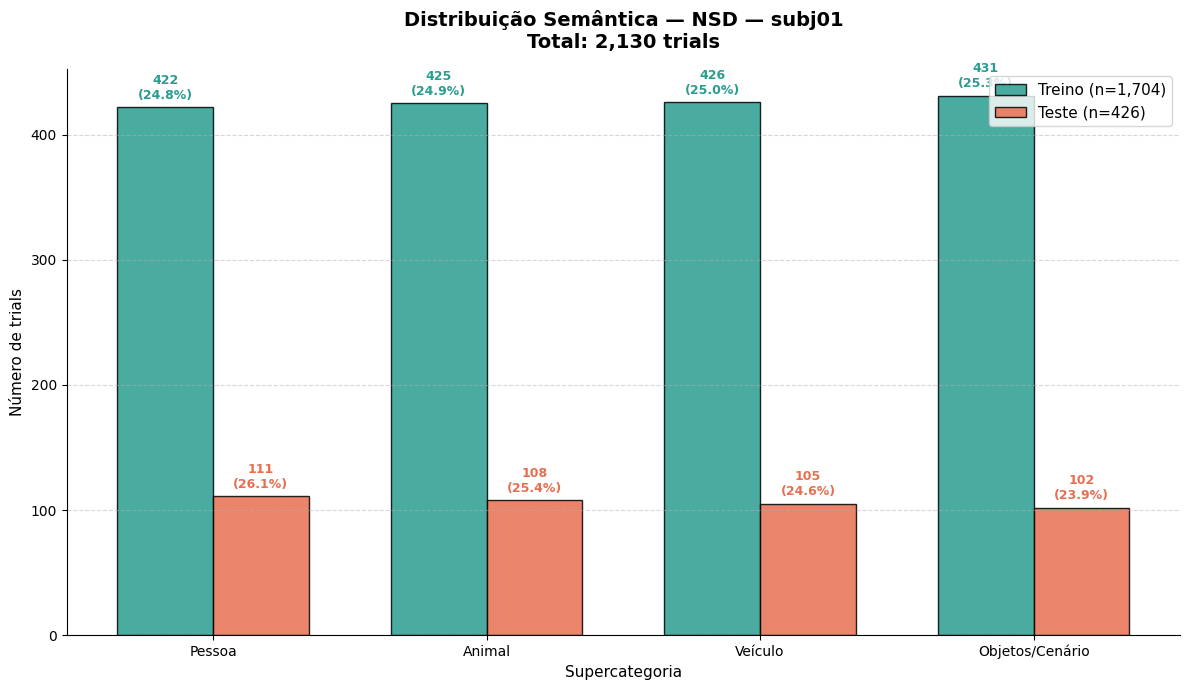

[plot] Salvo em 'nsd_distribution_train_test_nsd_—_subj01.png'


In [ ]:
contador_treino = Counter()
contador_teste  = Counter()

# Percorre os arquivos salvos para contar
train_dir = os.path.join(OUTPUT_DIR_TREINO, "subj01")
test_dir  = os.path.join(OUTPUT_DIR_TESTE, "subj01")

for fname in os.listdir(train_dir):
    if fname.endswith('.p'):
        data = torch.load(os.path.join(train_dir, fname))
        contador_treino[data['y']] += 1

for fname in os.listdir(test_dir):
    if fname.endswith('.p'):
        data = torch.load(os.path.join(test_dir, fname))
        contador_teste[data['y']] += 1

print(f"Treino: {sum(contador_treino.values())} trials")
print(f"Teste:  {sum(contador_teste.values())} trials")

# Plota distribuição separada
plot_distribution_train_test(contador_treino, contador_teste, titulo="NSD — subj01")